# 02 — Análise exploratória: perguntas e respostas

Este notebook não apresenta gráficos isolados: cada visualização responde a uma pergunta e é seguida de uma leitura dos resultados. A base contém registros de 2 de outubro de 2000 a 24 de setembro de 2023.

> **Como interpretar:** os resultados descrevem atributos registrados pela fonte. Não demonstram causalidade, responsabilidade legal ou completude dos registros.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Markdown, display

RAIZ_PROJETO = Path.cwd()
if not (RAIZ_PROJETO / 'src').exists():
    RAIZ_PROJETO = RAIZ_PROJETO.parent
sys.path.insert(0, str(RAIZ_PROJETO / 'src'))

from data_processing import PROCESSED_DATA_PATH
from analysis_utils import tabela_frequencia, fatalidades_por_ano, grafico_barras, grafico_linha_anual

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError('Execute primeiro o notebook 01_preprocessamento.ipynb.')
dados = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['date_of_event', 'date_of_death'])
print(f'Registros analisados: {len(dados):,}')

Registros analisados: 11,124


## Pergunta 1 — Em quais anos houve mais fatalidades registradas?

**Resposta.** O maior total anual ocorreu em **2014**, com **2,326 fatalidades**. O segundo maior foi em **2002**, com **1,326**. A série mostra forte variação entre anos; portanto, não é adequado resumir todo o período por uma única média anual.

,ano_obito,fatalidades
0,2000,35
1,2001,348
2,2002,1326
3,2003,732
4,2004,922
5,2005,240
6,2006,681
7,2007,400
8,2008,900
9,2009,1059


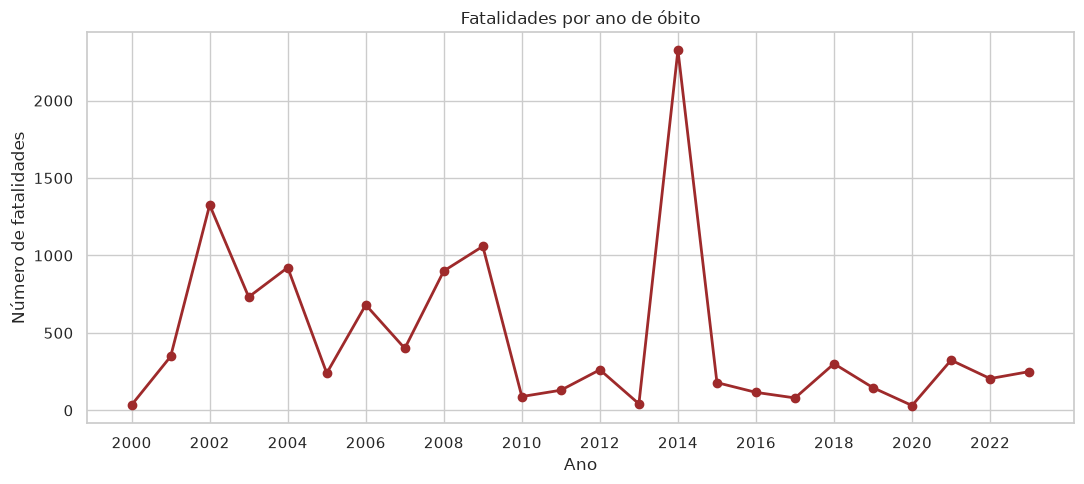

In [2]:
por_ano = fatalidades_por_ano(dados)
fig, _ = grafico_linha_anual(por_ano)
pico = por_ano.loc[por_ano['fatalidades'].idxmax()]
segundo_pico = por_ano.nlargest(2, 'fatalidades').iloc[1]
display(Markdown(f'''**Resposta.** O maior total anual ocorreu em **{int(pico['ano_obito'])}**, com **{int(pico['fatalidades']):,} fatalidades**. O segundo maior foi em **{int(segundo_pico['ano_obito'])}**, com **{int(segundo_pico['fatalidades']):,}**. A série mostra forte variação entre anos; portanto, não é adequado resumir todo o período por uma única média anual.'''))
por_ano

## Pergunta 2 — Qual cidadania aparece com maior frequência nos registros?

**Resposta.** Registros de pessoas com cidadania **Palestinian** representam **90.72%** da base (**10,092 registros**). Registros de cidadania israelense representam **9.25%**. Essas proporções descrevem esta base, não uma estimativa independente de todas as mortes do conflito.

,citizenship,fatalidades,percentual
0,Palestinian,10092,90.72
1,Israeli,1029,9.25
2,Jordanian,2,0.02
3,American,1,0.01


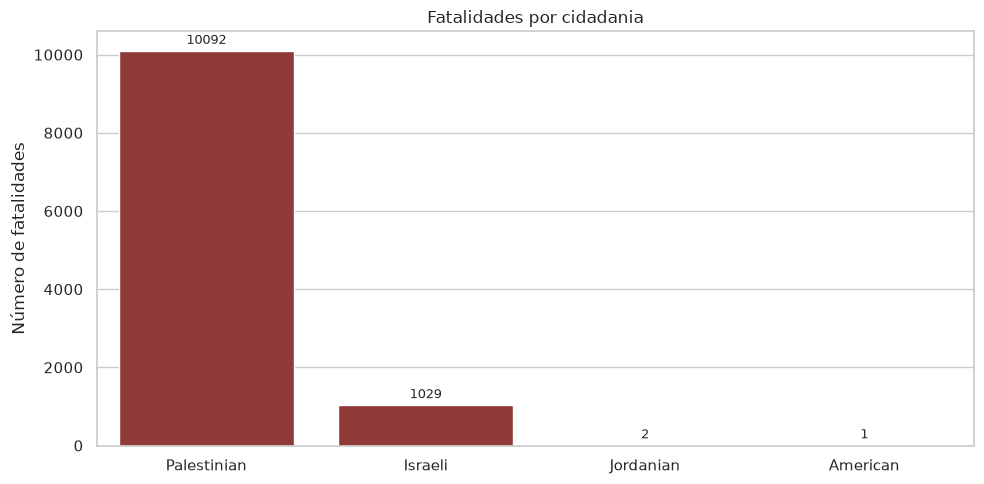

In [3]:
por_cidadania = tabela_frequencia(dados, 'citizenship')
fig, _ = grafico_barras(por_cidadania, 'citizenship', 'Fatalidades por cidadania', rotacao=0)
principal = por_cidadania.iloc[0]
display(Markdown(f'''**Resposta.** Registros de pessoas com cidadania **{principal['citizenship']}** representam **{principal['percentual']:.2f}%** da base (**{int(principal['fatalidades']):,} registros**). Registros de cidadania israelense representam **{por_cidadania.iloc[1]['percentual']:.2f}%**. Essas proporções descrevem esta base, não uma estimativa independente de todas as mortes do conflito.'''))
por_cidadania

## Pergunta 3 — Onde os eventos fatais se concentram?

**Resposta.** A **Gaza Strip** concentra **69.52%** dos registros (**7,733**), seguida por **West Bank** com **24.38%**. O gráfico aponta concentração geográfica nos registros, mas não explica sozinho suas causas.

,event_location_region,fatalidades,percentual
0,Gaza Strip,7733,69.52
1,West Bank,2712,24.38
2,Israel,679,6.10


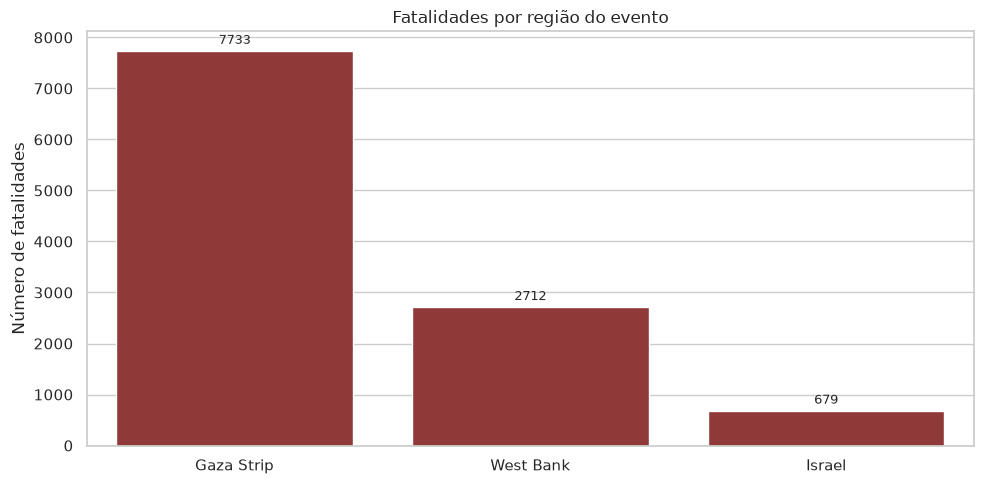

In [4]:
por_regiao = tabela_frequencia(dados, 'event_location_region')
fig, _ = grafico_barras(por_regiao, 'event_location_region', 'Fatalidades por região do evento', rotacao=0)
principal = por_regiao.iloc[0]
display(Markdown(f'''**Resposta.** A **{principal['event_location_region']}** concentra **{principal['percentual']:.2f}%** dos registros (**{int(principal['fatalidades']):,}**), seguida por **{por_regiao.iloc[1]['event_location_region']}** com **{por_regiao.iloc[1]['percentual']:.2f}%**. O gráfico aponta concentração geográfica nos registros, mas não explica sozinho suas causas.'''))
por_regiao

## Pergunta 4 — Qual faixa etária predomina e o que ocorre com os registros sem idade?

**Resposta.** Entre os **10,995** registros com idade, a faixa de **15–24 anos** é a mais frequente, com **44.50%**. Há **129** registros sem idade; eles foram excluídos apenas deste recorte, em vez de receber uma idade estimada.

,faixa_etaria,fatalidades,percentual
0,15–24,4893,44.50
1,25–34,2723,24.77
2,0–14,1164,10.59
3,35–44,1002,9.11
4,45–54,616,5.60
5,55–64,323,2.94
6,65+,274,2.49


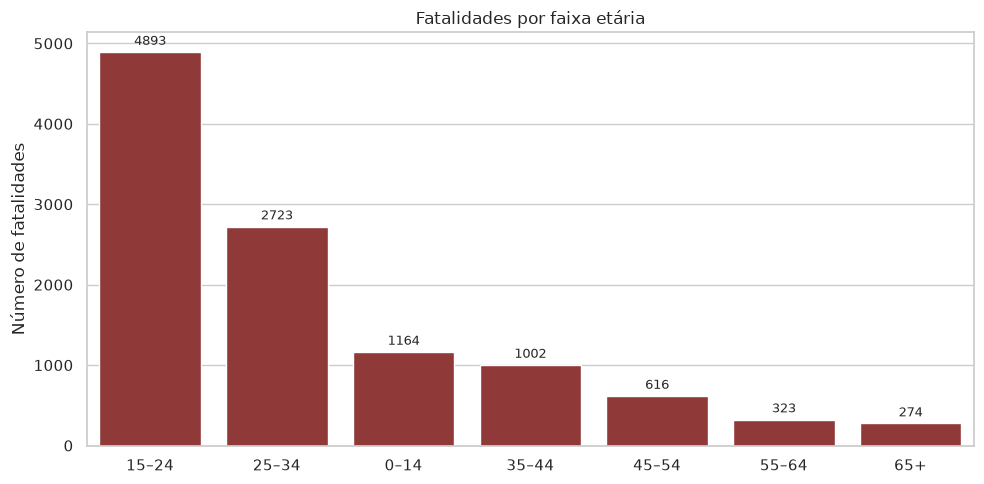

In [5]:
dados_com_idade = dados.dropna(subset=['faixa_etaria'])
por_faixa_etaria = tabela_frequencia(dados_com_idade, 'faixa_etaria')
fig, _ = grafico_barras(por_faixa_etaria, 'faixa_etaria', 'Fatalidades por faixa etária', rotacao=0)
principal = por_faixa_etaria.iloc[0]
idades_ausentes = dados['age'].isna().sum()
display(Markdown(f'''**Resposta.** Entre os **{len(dados_com_idade):,}** registros com idade, a faixa de **{principal['faixa_etaria']} anos** é a mais frequente, com **{principal['percentual']:.2f}%**. Há **{idades_ausentes:,}** registros sem idade; eles foram excluídos apenas deste recorte, em vez de receber uma idade estimada.'''))
por_faixa_etaria

## Pergunta 5 — O que a fonte registra sobre participação em hostilidades?

**Resposta.** A fonte marca **41.83%** dos registros como `No` e **31.17%** como `Yes`. Em **18.28%**, o campo está como `Desconhecido`. Esta variável deve ser lida como uma classificação presente na fonte — não como validação independente do envolvimento de cada pessoa.

,took_part_in_the_hostilities,fatalidades,percentual
0,No,4653,41.83
1,Yes,3467,31.17
2,Desconhecido,2033,18.28
3,Israelis,771,6.93
4,Object of targeted killing,200,1.80


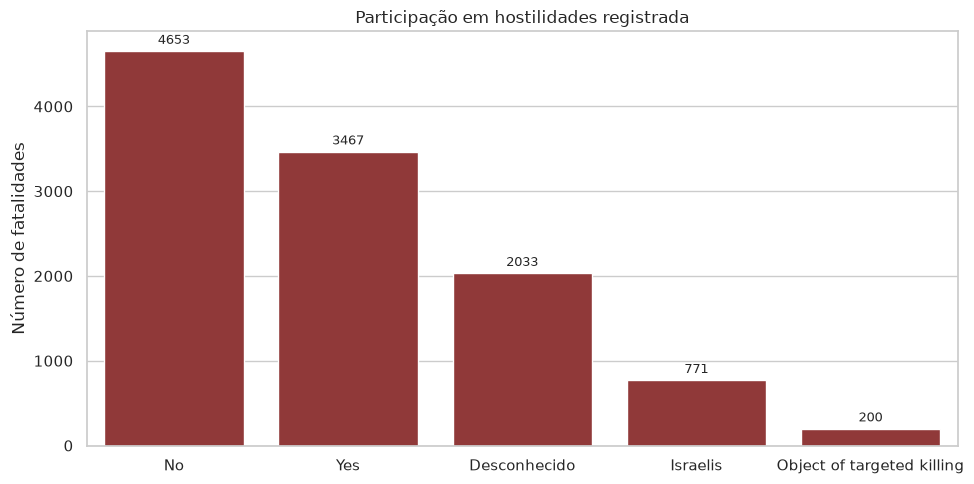

In [6]:
por_hostilidades = tabela_frequencia(dados, 'took_part_in_the_hostilities')
fig, _ = grafico_barras(por_hostilidades, 'took_part_in_the_hostilities', 'Participação em hostilidades registrada', rotacao=0)
nao = por_hostilidades.loc[por_hostilidades['took_part_in_the_hostilities'] == 'No'].iloc[0]
sim = por_hostilidades.loc[por_hostilidades['took_part_in_the_hostilities'] == 'Yes'].iloc[0]
desconhecido = por_hostilidades.loc[por_hostilidades['took_part_in_the_hostilities'] == 'Desconhecido'].iloc[0]
display(Markdown(f'''**Resposta.** A fonte marca **{nao['percentual']:.2f}%** dos registros como `No` e **{sim['percentual']:.2f}%** como `Yes`. Em **{desconhecido['percentual']:.2f}%**, o campo está como `Desconhecido`. Esta variável deve ser lida como uma classificação presente na fonte — não como validação independente do envolvimento de cada pessoa.'''))
por_hostilidades

## Pergunta 6 — A data do evento é sempre igual à data do óbito?

In [7]:
mortes_posteriores = (dados['dias_ate_obito'] > 0).sum()
percentual = mortes_posteriores / len(dados) * 100
maior_defasagem = dados['dias_ate_obito'].max()
display(Markdown(f'''**Resposta.** Não. Em **{mortes_posteriores:,} registros ({percentual:.2f}%)**, o óbito ocorreu depois da data do evento; a maior defasagem registrada é de **{int(maior_defasagem):,} dias**. Por isso, a série temporal deste notebook usa o ano do óbito e mantém as duas datas separadas.'''))

**Resposta.** Não. Em **910 registros (8.18%)**, o óbito ocorreu depois da data do evento; a maior defasagem registrada é de **3,723 dias**. Por isso, a série temporal deste notebook usa o ano do óbito e mantém as duas datas separadas.

## Síntese

A análise evidencia concentração temporal e geográfica dos registros, predominância de determinadas faixas etárias entre os casos com idade conhecida e incerteza relevante em classificações de hostilidades. Os gráficos respondem a perguntas descritivas; para explicar por que os padrões ocorrem, seriam necessárias fontes contextuais adicionais e uma estratégia de pesquisa causal.